<a href="https://colab.research.google.com/github/Valepowell/Examen2/blob/main/Examen_de_certificaci%C3%B3n_%E2%80%93_Intento_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Limpieza de datos con Python:**
- Detección y eliminación de valores duplicados: Asegúrate de que cada registro en el dataset sea único.
- Verificación y ajuste de tipos de datos: Asegúrate de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.
- Consistencia en valores categóricos: Identifica y corrige cualquier inconsistencia en los valores categóricos (por ejemplo, ‘yes’, ‘Yes’, ‘YES’).
- Manejo de valores faltantes: Identifica y maneja cualquier valor faltante en el dataset. Rellena los valores faltantes con un marcador adecuado para el tipo de dato.
- Detección de datos anómalos: Identifica y corrige cualquier punto de dato inapropiado o inusual (por ejemplo, una estancia de 1000 noches).


Entrega

Un archivo .ipynb claramente comentado con todo el código utilizado para la limpieza y exploración de datos. Para cumplir con los requisitos anteriores, este archivo tendrá un mínimo de 4 visualizaciones.
Subir un repositorio a una plataforma de control de versiones (por ejemplo, GitHub) con un TAG incluido para verificar la fecha de entrega. El repositorio debe contener el archivo .ipynb.
NOTA: Debes enviar un archivo y un enlace al repositorio con el TAG correspondiente. Las presentaciones de enlaces sin el archivo o sin el TAG serán consideradas no presentadas.

In [127]:
# Usamos la biblioteca google para poder usar archivos en nuestro drive.
from google.colab import drive
# Este comando conecta colab con drive.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [128]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [129]:
# Cargar el dataset
# Importamos una bbdd en formato excel y lo guardamos en una variable.
path = "/content/drive/MyDrive/BBDD/hotel_bookings.csv"
df = pd.read_csv(path)

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [131]:
# Revisar los typo de datos.
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [132]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [133]:
# Orden de la data sacando espacions y dejandola en minúsculas.
df.columns = df.columns.str.lower().str.strip()

In [134]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [135]:
# Revisar duplicados. No hay
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
119385,False
119386,False
119387,False
119388,False


In [136]:
# Identificar valores nulos en todo el DataFrame, se visualizan:
# children     4
# country    488
# agent    16340
# company 112593
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [137]:
# Comenzamos viendo los null de country    488
df["country"].value_counts().sort_index()

,count
country,
ABW,2
AGO,362
AIA,1
ALB,12
AND,7
...,...
VGB,1
VNM,8
ZAF,80


In [138]:
df['country'] = df['country'].str.strip()
print(df.isnull().sum())

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [139]:
# Podemos revisar datos, no se visualizan los Nulos.
df.groupby(["country"]).size().sort_index()

,0
country,
ABW,2
AGO,362
AIA,1
ALB,12
AND,7
...,...
VGB,1
VNM,8
ZAF,80


In [140]:
# Comenzamos viendo los null de country, 488 registros.
df[df["country"].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
30,Resort Hotel,0,118,2015,July,27,1,4,10,1,...,No Deposit,NaN,NaN,0,Transient,62.0,0,2,Check-Out,2015-07-15
4127,Resort Hotel,1,0,2016,February,8,15,0,0,0,...,No Deposit,NaN,383.0,0,Transient,0.0,0,0,Canceled,2016-02-15
7092,Resort Hotel,1,8,2016,July,30,21,0,1,1,...,No Deposit,NaN,204.0,0,Transient,73.0,0,2,Canceled,2016-07-20
7860,Resort Hotel,1,39,2016,August,36,30,0,5,2,...,No Deposit,NaN,NaN,0,Transient,159.0,0,5,Canceled,2016-07-22
8779,Resort Hotel,1,0,2016,October,42,13,0,1,1,...,No Deposit,NaN,457.0,0,Transient,50.0,0,0,Canceled,2016-10-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65908,City Hotel,1,0,2017,April,15,10,0,0,0,...,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
65909,City Hotel,1,0,2017,April,15,10,0,0,0,...,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
65910,City Hotel,1,0,2017,April,15,10,0,0,0,...,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
80830,City Hotel,0,4,2015,November,48,23,1,2,1,...,No Deposit,37.0,NaN,0,Transient-Party,70.0,0,0,Check-Out,2015-11-26


Nota: Al analizar la data no es posible identificar a que pais conrresponden los NaN (Nulos) de Country, por lo que se imputaran con "Desconocido"

In [141]:
# imputar valores nulos con "Desconicido"
df['country'].fillna('Desconocido', inplace=True)

In [142]:
# Revision de Imputacion de los null de country, 488 registros.
df[df["country"].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [143]:
# Convierte a tipo entero para trabajar los nulos
df['agent'] = df['agent'].astype('Int64')

# Comenzamos viendo los null de agent, 16340 registros.
df[df["agent"].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,<NA>,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,<NA>,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,<NA>,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,<NA>,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
18,Resort Hotel,0,0,2015,July,27,1,0,1,2,...,No Deposit,<NA>,110.0,0,Transient,107.42,0,0,Check-Out,2015-07-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119124,City Hotel,0,0,2017,August,35,29,0,1,1,...,No Deposit,<NA>,72.0,0,Transient,0.00,0,2,Check-Out,2017-08-30
119151,City Hotel,0,0,2017,August,35,29,0,1,2,...,No Deposit,<NA>,NaN,0,Transient,270.00,0,0,Check-Out,2017-08-30
119166,City Hotel,0,0,2017,August,35,30,0,1,1,...,No Deposit,<NA>,NaN,0,Transient,140.00,0,0,Check-Out,2017-08-31
119215,City Hotel,0,2,2017,August,35,31,0,1,1,...,No Deposit,<NA>,NaN,0,Transient,140.00,0,2,Check-Out,2017-09-01


In [144]:
# Agrupamos por agente  para ver los tipos de datos, no se visualizan los Nulos.
df.groupby(["agent"]).size().sort_index()

,0
agent,
1,7191
2,162
3,1336
4,47
5,330
...,...
510,2
526,10
527,35


Nota: Al analizar la data no es posible identificar a que agente conrresponden los NaN (Nulos), por lo que se imputaran con valor 0, que significa "Sin agente"

In [145]:
# imputar valores nulos con '0': Sin agente
df['agent'].fillna(0, inplace=True)

In [146]:
# Revision de Imputacion de los null de agent, 16340 registros.
df[df["agent"].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [147]:
# Comenzamos viendo los null de company
df["company"].value_counts().sort_index()

,count
company,
6.0,1
8.0,1
9.0,37
10.0,1
11.0,1
...,...
531.0,1
534.0,2
539.0,2


In [148]:
# Agrupamos por agente  para ver los datos si se relaciona con los agentes nulos.
df.groupby(["agent"])["company"].size().sort_index()

,company
agent,
0,16340
1,7191
2,162
3,1336
4,47
...,...
510,2
526,10
527,35


In [149]:
# Revision de Imputacion de los null de agent, 16340 registros.
df[df["company"].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


Nota: Dado que no es posible recuperar o identificar el dato company, la columna será eliminada de la data

In [150]:
# Eliminacion de columna por contener muy poco datos utiles
df.drop(columns=['company'], inplace=True)

In [151]:
# Revisamos nuevamente los datos faltantes y nos queda Children con 4 nulos
print(df.isnull().sum())

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          4
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [152]:
# Revisión de children.
df[df["children"].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,0,No Deposit,0,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,0,No Deposit,14,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,0,No Deposit,0,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,0,No Deposit,9,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [153]:
# Convierte a tipo entero para trabajar los nulos
df['children'] = df['children'].astype('Int64')

# Comenzamos viendo los null de children 4 registros.
df[df["children"].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,0,No Deposit,0,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,0,No Deposit,14,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,0,No Deposit,0,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,0,No Deposit,9,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [154]:
# imputar valores nulos con '0': Sin niños
df['children'].fillna(0, inplace=True)

In [155]:
# Validacion de imputacion de los null de children 4 registros.
df[df["children"].isna()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date


In [156]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.0,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.0,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,74.828319,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,107.141953,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,7.0,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,9.0,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,152.0,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.0,10.000000,1.000000,26.000000,72.000000,21.000000,535.0,391.000000,5400.000000,8.000000,5.000000


In [157]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [158]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,0,No Deposit,0,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,0,No Deposit,303,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,0,No Deposit,240,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,0,No Deposit,15,0,Transient,105.5,0,0,Canceled,2015-04-22


En el segmnto sigueinte se revisan los datos de tipo Objet para ver inconsitencia de data

In [159]:
# Agrupamos para ver consistencia de los datos.
df.groupby(["deposit_type"])["customer_type"].size().sort_index()

,customer_type
deposit_type,
No Deposit,104641
Non Refund,14587
Refundable,162


In [160]:
# Agrupamos para ver consistencia de los datos.
df.groupby("customer_type").size().sort_index()

,0
customer_type,
Contract,4076
Group,577
Transient,89613
Transient-Party,25124


In [161]:
# Agrupamos para ver consistencia de los datos.
df.groupby("reservation_status").size().sort_index()

,0
reservation_status,
Canceled,43017
Check-Out,75166
No-Show,1207


In [162]:
# Reemplazamos los valores indefinidor por "Sin_dato"
df['market_segment'] = df['market_segment'].replace('Undefined', 'sin_dato')

In [163]:
# Agrupamos para ver consistencia de los datos.
df.groupby("meal").size().sort_index()

,0
meal,
BB,92310
FB,798
HB,14463
SC,10650
Undefined,1169


In [164]:
# Reemplazamos los valores indefinidor por "Sin_dato"
df['meal'] = df['meal'].replace('Undefined', 'sin_dato')

In [165]:
# Agrupamos para ver consistencia de los datos.
df.groupby("meal").size().sort_index()

,0
meal,
BB,92310
FB,798
HB,14463
SC,10650
sin_dato,1169


In [166]:
# Agrupamos para ver consistencia de los datos.
df.groupby("market_segment").size().sort_index()

,0
market_segment,
Aviation,237
Complementary,743
Corporate,5295
Direct,12606
Groups,19811
Offline TA/TO,24219
Online TA,56477
sin_dato,2


In [167]:
# Reemplazamos los valores indefinidor por "Sin_dato"
df['market_segment'] = df['market_segment'].replace('Undefined', 'sin_dato')

In [168]:
# Agrupamos para ver consistencia de los datos.
df.groupby("market_segment").size().sort_index()

,0
market_segment,
Aviation,237
Complementary,743
Corporate,5295
Direct,12606
Groups,19811
Offline TA/TO,24219
Online TA,56477
sin_dato,2


In [169]:
# Agrupamos para ver consistencia de los datos.
df.groupby("distribution_channel").size().sort_index()

,0
distribution_channel,
Corporate,6677
Direct,14645
GDS,193
TA/TO,97870
Undefined,5


In [170]:
# Reemplazamos los valores indefinidor por "Sin_dato"
df['distribution_channel'] = df['distribution_channel'].replace('Undefined', 'sin_dato')

In [171]:
# Agrupamos para ver consistencia de los datos.
df.groupby("distribution_channel").size().sort_index()

,0
distribution_channel,
Corporate,6677
Direct,14645
GDS,193
TA/TO,97870
sin_dato,5


In [172]:
# Agrupamos para ver consistencia de los datos.
df.groupby("reservation_status").size().sort_index()

,0
reservation_status,
Canceled,43017
Check-Out,75166
No-Show,1207


In [173]:
# Agrupamos para ver consistencia de los datos.
df.groupby("reservation_status_date").size().sort_index()

,0
reservation_status_date,
2014-10-17,180
2014-11-18,1
2015-01-01,763
2015-01-02,16
2015-01-18,1
...,...
2017-09-08,4
2017-09-09,6
2017-09-10,4


In [174]:
# Agrupamos para ver consistencia de los datos.
df.groupby("reservation_status_date").size().sort_index()

,0
reservation_status_date,
2014-10-17,180
2014-11-18,1
2015-01-01,763
2015-01-02,16
2015-01-18,1
...,...
2017-09-08,4
2017-09-09,6
2017-09-10,4


In [175]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240,0,Transient,98.0,0,1,Check-Out,2015-07-03


**2. Exploración de datos con Python:**
- Visualizaciones exploratorias univariadas: Crea dos tipos diferentes de visualizaciones univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.



In [176]:
# Crear columnas adicionales para calcular el total de noches
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
# Agrupamos para ver consistencia de los datos.
df.groupby('total_nights').size().sort_index()

,0
total_nights,
0,715
1,21020
2,27643
3,27076
4,17383
5,7784
6,3857
7,8655
8,1161


In [177]:
# Validamos la creacion de la columna total_nights
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304,0,Transient,75.0,0,0,Check-Out,2015-07-02,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240,0,Transient,98.0,0,1,Check-Out,2015-07-03,2


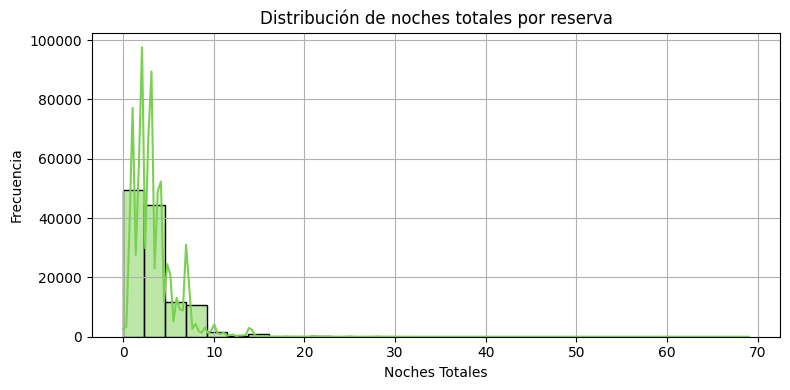

In [178]:
# Visualizacion 1: UNIVARIADA 1: Histograma de noches totales por reserva

plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='total_nights', bins=30, kde=True, color="#7AD151FF")
plt.title('Distribución de noches totales por reserva')
plt.xlabel('Noches Totales')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.tight_layout()
plt.show()

# Interpretación:
# El gráfico nos muestra que la mayor consentracion de reservas son de 1 a 7 noches,
# donde el mayor valor es de 2 y 3 noches.
# tambien se ven valore atipicos sobre los 20 días y casi nulo sobre 31 días

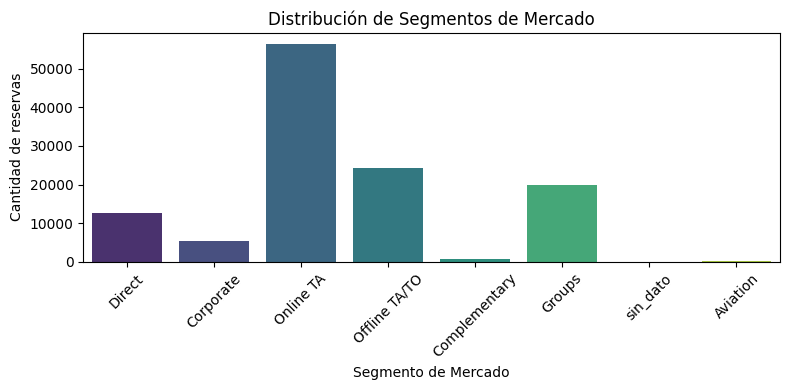

In [179]:
# Visualizacion 1: UNIVARIADA 2: Conteo de segmentos de mercado (market_segment)

df.groupby('market_segment').size().sort_index()

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='market_segment', palette='viridis')
plt.title('Distribución de Segmentos de Mercado')
plt.xlabel('Segmento de Mercado')
plt.ylabel('Cantidad de reservas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Interpretación:
# la Mayoría de las reservaciones se hacer por la agencia Online TA
# muy poer debajo se encunetran las agencias Offline TA/TO y groups
# lo que puede indicar según el nobre de la agencia que las reservas se hacen mayormente en forma Online

- Visualizaciones exploratorias multivariadas: Crea dos tipos diferentes de visualizaciones multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

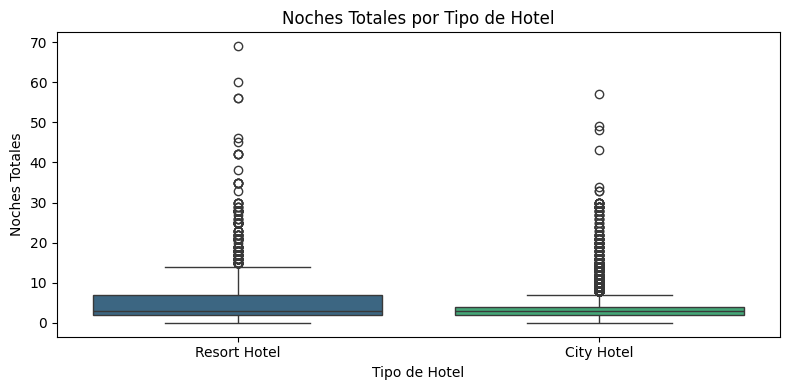

In [180]:
# Visualizacion 2: MULTIVARIADA 1: Boxplot de noches totales por tipo de hotel

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='hotel', y='total_nights', palette='viridis')
plt.title('Noches Totales por Tipo de Hotel')
plt.xlabel('Tipo de Hotel')
plt.ylabel('Noches Totales')
plt.tight_layout()
plt.show()

# Interpretación:
# del primer boxplot podemos ver que Resort Hotel tiene estadias mas largas, por
# lo que se podría suponer que en este segmento se agrupan los hoteles de vacaciones
# mientras que en City Hotel las reservaciones son mas cortas, no son usados para vacacionar.

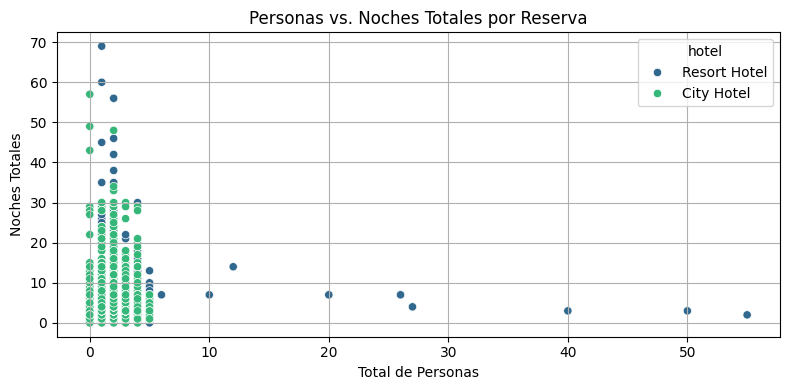

In [181]:
# Visualizacion 2: MULTIVARIADA 2: Dispersión entre personas y noches por reserva

df['total_people'] = df['adults'] + df['children'].fillna(0)

plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='total_people', y='total_nights', hue='hotel', palette='viridis')
plt.title('Personas vs. Noches Totales por Reserva')
plt.xlabel('Total de Personas')
plt.ylabel('Noches Totales')
plt.grid(True)
plt.tight_layout()
plt.show()

# Interpretación:
# Del gráfico se puede interpretar que la mayoría de las reservaciones son entre 1 a 3 personas.
# con una variada duracion de la estadía en noches, siendo muy escazas las reservaciones de grupos de mas de 10 personas.

**3. Análisis adicional:**
- Estadísticas descriptivas: Proporciona un resumen estadístico del dataset, incluyendo medidas de tendencia central y dispersión para las variables numéricas.
- Identificación de tendencias: Analiza y discute cualquier tendencia notable que observes en los datos, apoyándote en las visualizaciones y estadísticas descriptivas.

In [182]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0
children,119390.0,0.103886,0.398555,0.0,0.0,0.0,0.0,10.0
babies,119390.0,0.007949,0.097436,0.0,0.0,0.0,0.0,10.0


**Estadísticas descriptivas:**


1.  Se puede ver que en promedio las estadias son de 3.4 noches

2. el promedio de personas por reservacion es de 1.9 personas
3. El valor promedio de las tarifas es de $101.83
4. gran cantidad de las reservaciones se realizan por medio de agencias
5. El promedio de días con que se realiza una reservacion es de 104 días


**Identificación de tendencias**


1. La mayoria de las reservaciones se realiza por la agencoa Online TA, lo que se puede entender que se realizan por internet
2. Las estadias mas largas son los Resort Hotel.
3. Se realizan pocas reservaciones grupales para mas de 10 personas
4. La mayoría de las reservaciones son de 1 a 3 personas
5. La estadias en los City hotel son cortas.



**Conclusión General:**
La mayoría de las reseravaciones son de grupos pequeños de hasta 3 personas, gran parte de estas reservaciones son realiadas en online a travées de la agencia Online TA.
Las estadias más largas son los Resort Hotel, por lo que se supone que son vacaionales y los City Hotel se usan mas a nivel de viajes cortos, lo que se interpreta como viajes de negocios o turisticos.
Las reservaciones se realizan con al menos 3 meses de anticipación por lo cual son viajes programados con meses de anticipación.
Las estadias son de 2 a 7 noches y como se dijo anteriromente suelen ser grupos pequeños. En su mayoria personas adultas con muy pocos niños y bebés.